# Interest Rate XVA

This notebook prices an **EUR Interest Rate Swap** and computes **XVA metrics** using:

- A **Hull-White one-factor** model for Monte Carlo simulation of interest rate paths
- Pathwise re-pricing to build the full **Exposure** profile (EE / EPE / ENE)
- A flat **hazard-rate** default curve for the counterparty

The main output is the **uCVA** (Unilateral Credit Valuation Adjustment).

---

In [1]:
import tensorquant as tq
import matplotlib.pyplot as plt
import datetime
import pandas as pd
from dateutil.relativedelta import relativedelta
from tensorflow import stack, reduce_mean
import numpy as np

## 1. Setup

In [2]:
ref_date = datetime.date(2026, 2, 25)
tq.Settings.evaluation_date = ref_date
calendar = tq.TARGET()

## 2. Market Data

Build the **ESTR** (overnight) and **EUR 6M** forward curves from bootstrapped zero-coupon bond prices, then assemble a `MarketEnvironment`.

In [3]:
disc_factor = [1.0, 0.99994584, 0.99989168, 0.99951658, 0.9991406 , 0.9987649 ,
       0.99839065, 0.99673568, 0.99514101, 0.99339432, 0.99192323,
       0.99029715, 0.98863157, 0.98713775, 0.98554218, 0.9839551 ,
       0.98242782, 0.98089875, 0.97629874, 0.97153803, 0.96660517,
       0.96174842, 0.94138678, 0.91977351, 0.89721652, 0.87378833,
       0.84958351, 0.82498703, 0.80030163, 0.77553358, 0.75077035,
       0.72609428]
dates = [datetime.date(2026, 2, 25), datetime.date(2026, 2, 26), datetime.date(2026, 2, 27),
       datetime.date(2026, 3, 6), datetime.date(2026, 3, 13),
       datetime.date(2026, 3, 20), datetime.date(2026, 3, 27),
       datetime.date(2026, 4, 27), datetime.date(2026, 5, 27),
       datetime.date(2026, 6, 29), datetime.date(2026, 7, 27),
       datetime.date(2026, 8, 27), datetime.date(2026, 9, 28),
       datetime.date(2026, 10, 27), datetime.date(2026, 11, 27),
       datetime.date(2026, 12, 28), datetime.date(2027, 1, 27),
       datetime.date(2027, 2, 26), datetime.date(2027, 5, 27),
       datetime.date(2027, 8, 27), datetime.date(2027, 11, 29),
       datetime.date(2028, 2, 28), datetime.date(2029, 2, 27),
       datetime.date(2030, 2, 27), datetime.date(2031, 2, 27),
       datetime.date(2032, 2, 27), datetime.date(2033, 2, 28),
       datetime.date(2034, 2, 27), datetime.date(2035, 2, 27),
       datetime.date(2036, 2, 27), datetime.date(2037, 2, 27),
       datetime.date(2038, 2, 26)]

disc_factor_6m = [1.0, 0.99825187, 0.99637211, 0.99459776, 0.99271565, 0.99103902,
       0.98924461, 0.98738827, 0.9856945 , 0.98390642, 0.98210685,
       0.98045037, 0.97874674, 0.97689044, 0.97528109, 0.97354905,
       0.97171404, 0.97005217, 0.96832325, 0.95736063, 0.93499112,
       0.91160022, 0.88753418, 0.86291687, 0.83774287, 0.81241287,
       0.78703628, 0.76174335, 0.7366608 , 0.71196302, 0.68764535,
       0.66414527]
dates_6m = [datetime.date(2026, 2, 25), datetime.date(2026, 3, 27), datetime.date(2026, 4, 27),
       datetime.date(2026, 5, 27), datetime.date(2026, 6, 29),
       datetime.date(2026, 7, 27), datetime.date(2026, 8, 27),
       datetime.date(2026, 9, 28), datetime.date(2026, 10, 27),
       datetime.date(2026, 11, 27), datetime.date(2026, 12, 29),
       datetime.date(2027, 1, 27), datetime.date(2027, 2, 26),
       datetime.date(2027, 3, 30), datetime.date(2027, 4, 27),
       datetime.date(2027, 5, 27), datetime.date(2027, 6, 28),
       datetime.date(2027, 7, 27), datetime.date(2027, 8, 26),
       datetime.date(2028, 2, 28), datetime.date(2029, 2, 27),
       datetime.date(2030, 2, 27), datetime.date(2031, 2, 27),
       datetime.date(2032, 2, 27), datetime.date(2033, 2, 28),
       datetime.date(2034, 2, 27), datetime.date(2035, 2, 27),
       datetime.date(2036, 2, 27), datetime.date(2037, 2, 27),
       datetime.date(2038, 2, 26), datetime.date(2039, 2, 28),
       datetime.date(2040, 2, 27)]


estr_curve = tq.RateCurve.from_zcb(ref_date, dates, disc_factor, "LINEAR", tq.DayCounterConvention.Actual360)
eur6m_curve = tq.RateCurve.from_zcb(ref_date, dates_6m, disc_factor_6m, "LINEAR", tq.DayCounterConvention.Actual360)

# disc_curve = tq.RateCurve.from_zcb(ref_date, curve_date_grid, disc_factors, "LINEAR", tq.DayCounterConvention.Actual365)
# eur6m_curve = tq.RateCurve.from_zcb(ref_date, curve_date_grid, disc_factors, "LINEAR", tq.DayCounterConvention.Actual360)

market = {
    "IR:EUR:ESTR:SPOT":    estr_curve,   
    "IR:EUR:6M:SPOT":    eur6m_curve
}
market_env = tq.MarketEnvironment(market)

## 3. Instrument – EUR Interest Rate Swap

Build a **pay-fixed EUR IRS**:

| Attribute | Value |
|-----------|-------|
| Currency | EUR |
| Notional | 100 M |
| Tenor | 10Y |
| Fixed leg | Annual, Actual/360, rate = 1% |
| Floating leg | 6M Euribor, semi-annual, Actual/360 |
| Settlement delay | T+3 |

In [4]:
currency = tq.Currency.EUR
mod_fol_convention = tq.BusinessDayConvention.ModifiedFollowing
daycount_fix = tq.DayCounterConvention.Actual360
daycount_flt = tq.DayCounterConvention.Actual360

settlement_delay = 3
period_fixed_leg = "1Y"
period_float_leg = "6M"
eur6m_index = tq.IborIndex(calendar, 6, tq.TimeUnit.Months, tq.Currency.EUR, 2)

irs_eur6m_generator = tq.SwapGenerator(currency, settlement_delay,
                                        period_fixed_leg, period_float_leg,
                                        mod_fol_convention, 100e6,
                                        daycount_fix, daycount_flt,
                                        calendar, eur6m_index)
swap = irs_eur6m_generator.build(trade_date=ref_date, quote=0.01, term="10Y")

## 4. Static Pricing

Price the swap on the reference date using the ESTR discount curve and the EUR 6M forward curve. DV01 sensitivities are computed via **automatic differentiation** (TensorFlow GradientTape).

In [5]:

swap_engine = tq.SwapPricer()
swap_engine.price(swap, market_env, True)
sensitivities = swap_engine.tape.gradient(swap.price, [swap_engine.disc_curve._rates, swap_engine.fwd_curve._rates])

print(f"NPV FixedLeg: {swap.fixed_leg.price :,.0f}")
print(f"NPV FloatingLeg: {swap.floating_leg.price :,.0f}")
########
print(f"NPV Swap: {swap.price :,.0f}")

NPV FixedLeg: -8,955,129
NPV FloatingLeg: 24,116,586
NPV Swap: 15,161,456


## 5. Monte Carlo Simulation

Simulate short-rate paths with a **Hull-White one-factor** model:

$$dr(t) = [\theta(t) - a\,r(t)]\,dt + \sigma\,dW(t)$$

where $a$ is the mean-reversion speed and $\sigma$ is the short-rate volatility. The drift $\theta(t)$ is calibrated to fit the initial ESTR curve exactly.

### Time Grid

Build a semi-annual discretisation grid spanning the life of the swap plus one year, which defines the simulation time steps $\{t_0, t_1, \ldots, t_N\}$.

In [6]:
schedule_gen = tq.ScheduleGenerator(calendar, tq.BusinessDayConvention.ModifiedFollowing)
end_date = calendar.advance(ref_date, 11, tq.TimeUnit.Years, tq.BusinessDayConvention.ModifiedFollowing)
discretization_grid = schedule_gen.generate(ref_date, end_date, 6, tq.TimeUnit.Months)
date_grid = tq.DateGrid(discretization_grid, tq.DayCounterConvention.ActualActual)
time_grid = date_grid.times #[daycounter.year_fraction(ref_date, d) for d in discretization_grid]

### 5.1 Hull-White Parameters & Path Generation

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Mean-reversion speed | $a$ | 0.14 |
| Short-rate volatility | $\sigma$ | 0.8% |
| Number of paths | $N$ | 1 000 |

In [7]:
a = 0.14
sigma = 0.008
n_paths=1000

hw = tq.HullWhiteProcess(estr_curve, a, sigma)
kernel = tq.GaussianPathGenerator(hw, date_grid)
kernel.simulate(n_paths)

### 5.2 Simulated Yield Curves

Reconstruct a full yield curve at each simulation date for every Monte Carlo path using the Hull-White analytical zero-coupon bond formula.

In [8]:
curve_tensor = []
for i in range(len(date_grid.dates)):
    curve_date = date_grid.dates[i]

    curve_dates = [curve_date]
    curve_dates += [curve_date + relativedelta(days=i) for i in range(1, 5)]
    curve_dates += [curve_date + relativedelta(weeks=i) for i in range(1, 3)]
    curve_dates += [curve_date + relativedelta(months=i) for i in range(1, 12)]
    curve_dates += [curve_date + relativedelta(years=i) for i in range(1, 15)]
    curve_dates += [
        curve_date + relativedelta(years=i) for i in [20, 25, 30, 40]
    ]
    curve_taus = [
        tq.DayCounter(tq.DayCounterConvention.ActualActual).year_fraction(
            curve_date, d
        )
        for d in curve_dates
    ]
    bonds_tmp = stack(
        [
            hw.zero_bond(
                date_grid.times[i],
                date_grid.times[i] + tau,
                kernel.state_variable[:, i],
            )
            for tau in curve_taus
        ]
    )  
    curve_tensor_tmp = tq.RateCurve.from_zcb(
        curve_date,
        curve_taus,
        bonds_tmp,
        "LINEAR",
        tq.DayCounterConvention.ActualActual,
    )
    curve_tensor.append(curve_tensor_tmp)

simulated_curves = curve_tensor

### 5.3 Fixings

Populate the IBOR fixing schedule from the simulated short-rate paths so that historical fixings are consistent with each simulated scenario.

In [9]:
transaction_fixing_dates = swap.floating_leg.display_flows()[
    "fixing_date"
].values
transaction_fixing_rates = np.zeros(shape=transaction_fixing_dates.shape[0])
simulated_fixing_dates = [
    swap.floating_leg.index.fixing_date(d) for d in date_grid.dates
]
simulated_fixing_rates = reduce_mean(
    kernel.state_variable, axis=0
).numpy()
simulated_fixing_rates[0] = 0.02
# create fixings lookup table
fixings_lookup_table = {}
for i in range(len(simulated_fixing_dates)):
    fixings_lookup_table[simulated_fixing_dates[i]] = simulated_fixing_rates[i]
# # add transaction fixing rates for a given date from fixings lookup table
for i in range(len(transaction_fixing_dates)):
    if transaction_fixing_dates[i] in fixings_lookup_table:
        transaction_fixing_rates[i] = fixings_lookup_table[
            transaction_fixing_dates[i]
        ]
    else:
        # find the nearest fixing from lookup table
        transaction_fixing_rates[i] = fixings_lookup_table.get(
            transaction_fixing_dates[i],
            fixings_lookup_table[
                min(
                    fixings_lookup_table.keys(),
                    key=lambda d: abs(d - transaction_fixing_dates[i]),
                )
            ],
        )
for i, d in enumerate(transaction_fixing_dates):
    swap.floating_leg.index.add_fixing(d, transaction_fixing_rates[i])

## 6. Exposure Profile

Re-price the swap on each simulated path and time step to obtain the **pathwise NPV**.

From the pathwise NPV matrix we derive:

* **EE** (Expected Exposure) $= \mathbb{E}[V(t_i)]$
* **EPE** (Expected Positive Exposure) $= \mathbb{E}[\max(V(t_i), 0)]$
* **ENE** (Expected Negative Exposure) $= \mathbb{E}[\min(V(t_i), 0)]$

In [10]:
exposure = []
swap_engine = tq.SwapPricer()

for i in range(len(date_grid.dates)):
    market_sim = {
    "IR:EUR:ESTR:SPOT":    simulated_curves[i],   
    "IR:EUR:6M:SPOT":    simulated_curves[i]
    }
    market_env_sim = tq.MarketEnvironment(market_sim)
    # market_simulated[swap.discount_curve] = simulated_curves[i]
    # market_simulated[swap.estimation_curve] = simulated_curves[i]
    val_date = date_grid.dates[i]
    tq.Settings.evaluation_date = val_date
    if date_grid.dates[i] > swap.end_date:
        pv = np.zeros(shape=(n_paths,), dtype=np.float64)
    else:
        swap_engine.price(swap, market_env_sim)
        pv = swap.price
    exposure.append(pv)
exposure = stack(exposure, axis=0)
expected_exposure = reduce_mean(exposure, axis=1)

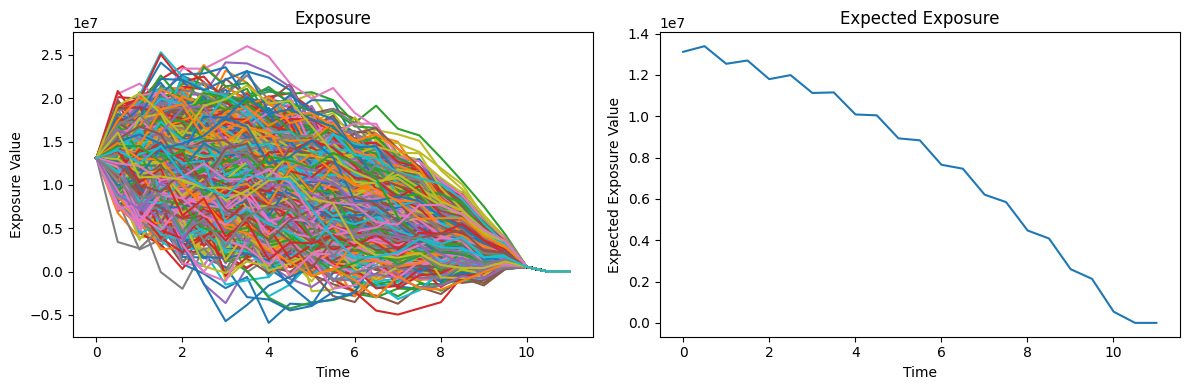

In [11]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 

ax[0].plot(date_grid.times, exposure)
ax[0].set_title("Exposure")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Exposure Value")

ax[1].plot(date_grid.times, expected_exposure)
ax[1].set_title("Expected Exposure")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Expected Exposure Value")

plt.tight_layout()  # Adjust spacing between plots
plt.show()

## uCVA – Unilateral Credit Valuation Adjustment

The unilateral CVA from the perspective of the bank (counterparty defaults, bank does not) is:

$$
\text{uCVA} = (1 - R) \sum_{i=1}^{N} \text{EPE}(t_i) \cdot P(0, t_i) \cdot \text{PD}(t_{i-1}, t_i)
$$

where
* $\text{EPE}(t_i) = \mathbb{E}[\max(V(t_i), 0)]$ – expected **positive** exposure  
* $P(0, t_i)$ – risk-free discount factor  
* $\text{PD}(t_{i-1}, t_i) = Q(t_{i-1}) - Q(t_i)$ – marginal probability of default  
* $R$ – recovery rate (typically 40 %)


### Default Curve

Model the counterparty default probability with a **flat hazard rate** $\lambda$:

$$Q(0,t)=e^{-\lambda t}$$

The marginal default probability in $[t_{i-1}, t_i]$ is $Q(t_{i-1}) - Q(t_i)$.

In [12]:
# ── Default curve: flat 3% hazard rate ────────────────────────────────────────
hazard_rate = 0.03   # 3% flat
recovery    = 0.40   # 40% recovery

default_curve = tq.DefaultCurve.from_flat_hazard_rate(
    ref_date,
    hazard_rate,
    tq.DayCounterConvention.Actual365,
)

# Quick sanity check – survival probability at a few maturities
for yr in [1, 5, 10]:
    print(f"Q(0, {yr:2d}Y) = {default_curve.survival_prob(float(yr)):.4f}")


Q(0,  1Y) = 0.9704
Q(0,  5Y) = 0.8607
Q(0, 10Y) = 0.7408


### uCVA Computation

Discretise the formula using the simulation time grid:

$$\text{uCVA} \approx (1-R)\sum_{i=1}^{N} \text{EPE}(t_i)\cdot P(0,t_i)\cdot[Q(t_{i-1})-Q(t_i)]$$

In [13]:
# ── uCVA calculation ──────────────────────────────────────────────────────────
#
# EPE(t_i)  = E[max(V(t_i), 0)]   – expected positive exposure
# DF(t_i)   = risk-free discount factor from disc_curve
# PD(t_{i-1}, t_i) = Q(t_{i-1}) - Q(t_i)  – marginal default probability
#
# uCVA = (1 - R) * Σ_i  EPE(t_i) * DF(t_i) * PD(t_{i-1}, t_i)
# ------------------------------------------------------------------------------

tq.Settings.evaluation_date = ref_date   # reset after the simulation loop

times = np.array(date_grid.times)        # shape (N,)

# Expected Positive Exposure: E[max(V, 0)] per time step
exposure_np = np.array(exposure)         # (N, n_paths)
epe = np.mean(np.maximum(exposure_np, 0.0), axis=1)   # (N,)

# Risk-free discount factors at each time step
df = np.array([estr_curve.discount(float(t)) for t in times])   # (N,)

# Marginal PD: PD(t_{i-1}, t_i)  –  with t_0 = 0
times_ext = np.concatenate([[0.0], times])   # prepend t=0
marginal_pd = np.array([
    default_curve.marginal_pd(float(times_ext[i]), float(times_ext[i + 1]))
    for i in range(len(times))
])   # (N,)

# uCVA summation
ucva_profile = (1 - recovery) * epe * df * marginal_pd   # contribution per step
ucva = ucva_profile.sum()

print(f"uCVA = {ucva:,.0f}")
print(f"uCVA / Notional = {ucva / swap.notional * 1e4:.2f} bps")


uCVA = 1,222,513
uCVA / Notional = 122.25 bps


### Results

Plot the **EPE** profile and the per-period **uCVA contribution** across the life of the swap.

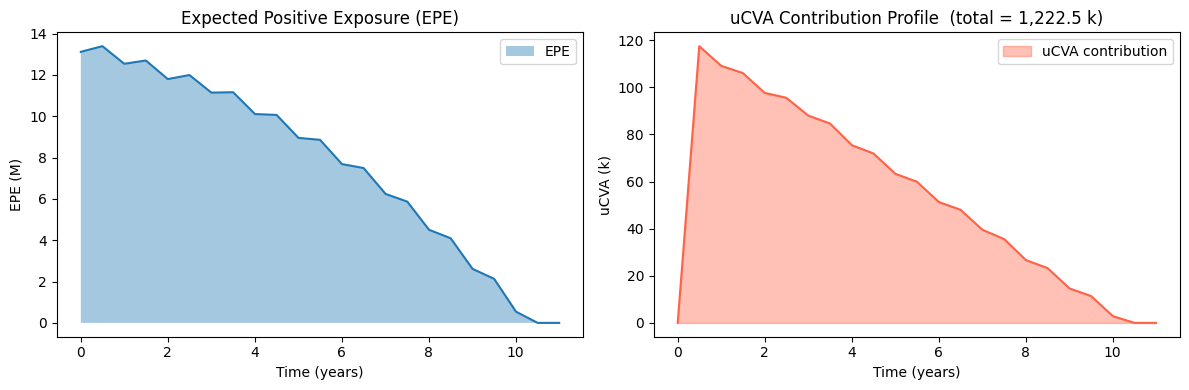

In [14]:
# ── Plot: EPE and uCVA contribution profile ───────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].fill_between(times, epe / 1e6, alpha=0.4, label="EPE")
ax[0].plot(times, epe / 1e6, lw=1.5)
ax[0].set_title("Expected Positive Exposure (EPE)")
ax[0].set_xlabel("Time (years)")
ax[0].set_ylabel("EPE (M)")
ax[0].legend()

ax[1].fill_between(times, ucva_profile / 1e3, alpha=0.4, color="tomato", label="uCVA contribution")
ax[1].plot(times, ucva_profile / 1e3, lw=1.5, color="tomato")
ax[1].set_title(f"uCVA Contribution Profile  (total = {ucva/1e3:,.1f} k)")
ax[1].set_xlabel("Time (years)")
ax[1].set_ylabel("uCVA (k)")
ax[1].legend()

plt.tight_layout()
plt.show()
